  CHECK 1 — File counts
  Images  : 5008
  Labels  : 5008
  Masks   : ⚠️  skipped (no mask directory found on Kaggle)
  Match   : ✅

  CHECK 2 — Label format
  Total labels : 5008
  Empty files  : 1305  (background images — OK)
  Total objects: 23788
  Format errors: 0
  Format       : ✅ all valid

  Polygon points:
    Min  : 3
    Max  : 90
    Mean : 11.6

  CHECK 3 — All 25 classes present
  ✅ C     :  2515  ██████████████████████████████
  ✅ R     :  1189  ██████████████████████████████
  ✅ U     :   535  ██████████████████████████
  ✅ J     :  7273  ██████████████████████████████
  ✅ L     :   478  ███████████████████████
  ✅ Q     :  7492  ██████████████████████████████
  ✅ P     :   163  ████████
  ✅ D     :   144  ███████
  ✅ IC    :   203  ██████████
  ✅ RN    :   628  ██████████████████████████████
  ✅ CR    :   708  ██████████████████████████████
  ✅ RA    :   104  █████
  ✅ M     :    88  ████ ← rare
  ✅ T     :   397  ███████████████████
  ✅ V     :   293  ██████████████


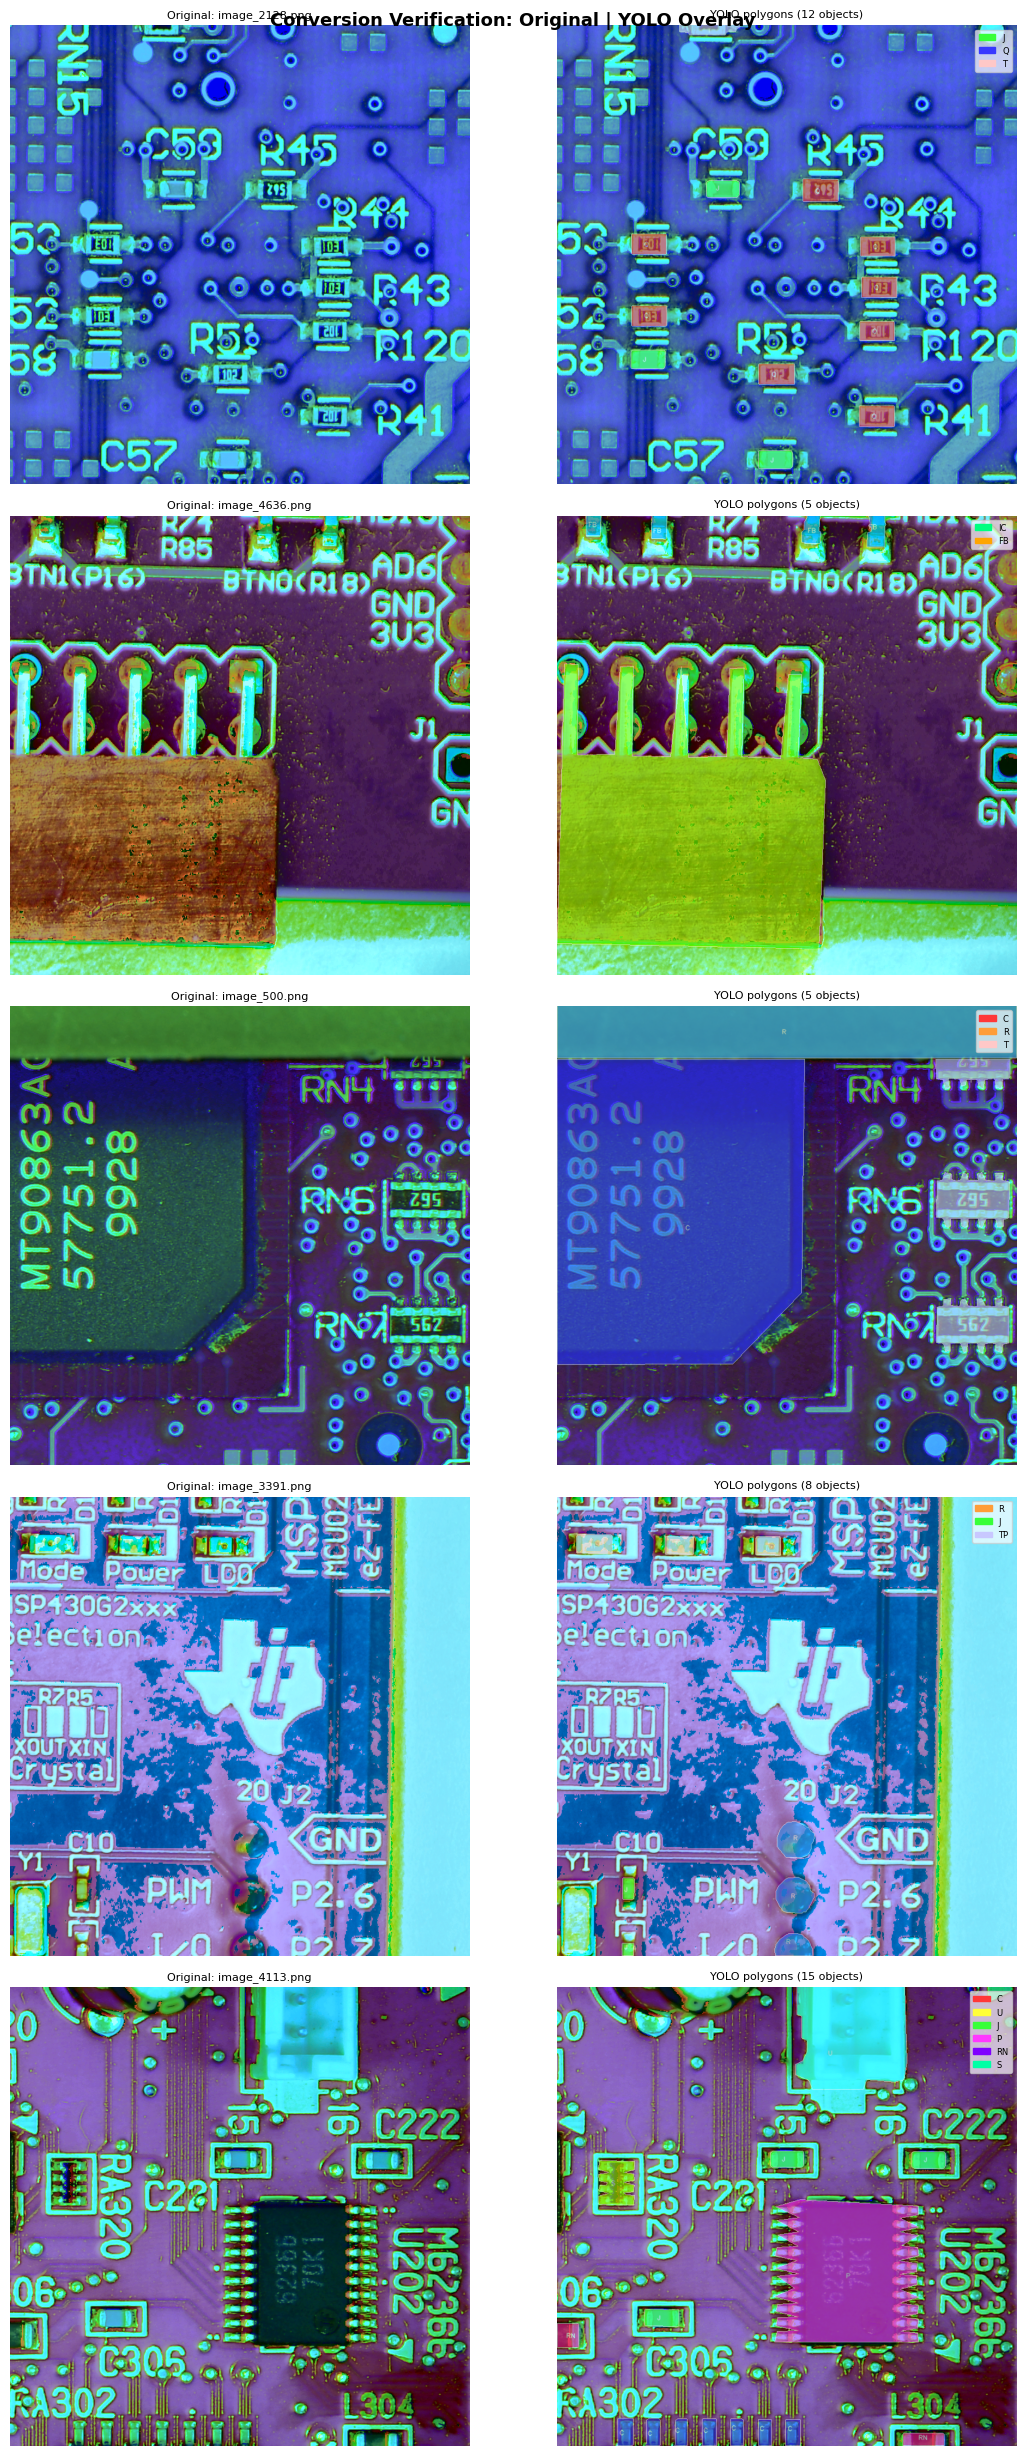


✅ Saved: /kaggle/working/verify_conversion.png

  FINAL VERDICT
  ✅  All 5008 labels present
  ✅  Zero format errors
  ✅  All 25 classes present
  ✅  Points in range 3-200

  ⚠️  Mask-vs-label cross-check skipped (masks not on Kaggle) — format/class/point checks above still validate the label files directly.

  ✅ Conversion confirmed correct!
  Next step: train YOLO11s


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import random

# ══════════════════════════════════════════════════════════════
# PATHS  (Kaggle)
# ══════════════════════════════════════════════════════════════
# Run `!ls /kaggle/input` once to confirm the exact dataset slug —
# Kaggle usually converts underscores to hyphens (yolo_new -> yolo-new)
YOLO_ROOT   = Path("/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo")
OUTPUT_ROOT = Path("/kaggle/working")   # input/ is read-only, so save here
SPLIT       = "train"

# Masks aren't uploaded to this Kaggle dataset — only images + labels.
# Leave this as None; the script will auto-skip mask checks if it's missing.
MASK_DIR = None  # e.g. Path("/kaggle/input/some-other-dataset/masks") if you add them later

CLASS_NAMES = [
    "C","R","U","J","L","Q","P","D","IC","RN",
    "CR","RA","M","T","V","TP","FB","S","BTN","CRA",
    "QA","LED","F","SW","JP"
]

VIZ_COLORS = [
    (255, 56, 56),(255,157, 56),(255,255, 56),( 56,255, 56),
    ( 56,255,255),( 56, 56,255),(255, 56,255),(255,128,  0),
    (  0,255,128),(128,  0,255),(255,  0,128),(128,255,  0),
    (  0,128,255),(255,200,200),(200,255,200),(200,200,255),
    (255,165,  0),(  0,255,165),(165,  0,255),(255, 80, 80),
    ( 80,255, 80),( 80, 80,255),(200,100,  0),(  0,200,100),
    (100,  0,200),
]

img_dir  = YOLO_ROOT / SPLIT / "images"
lbl_dir  = YOLO_ROOT / SPLIT / "labels"
mask_dir = MASK_DIR / SPLIT / "masks" if MASK_DIR else None
have_masks = mask_dir is not None and mask_dir.exists()

# ══════════════════════════════════════════════════════════════
# CHECK 1 — Counts
# ══════════════════════════════════════════════════════════════
print("=" * 55)
print("  CHECK 1 — File counts")
print("=" * 55)

imgs  = list(img_dir.glob("*.png"))  + list(img_dir.glob("*.jpg"))
lbls  = list(lbl_dir.glob("*.txt"))

print(f"  Images  : {len(imgs)}")
print(f"  Labels  : {len(lbls)}")
if have_masks:
    masks = list(mask_dir.glob("*.png"))
    print(f"  Masks   : {len(masks)}")
else:
    print(f"  Masks   : ⚠️  skipped (no mask directory found on Kaggle)")
print(f"  Match   : {'✅' if len(imgs)==len(lbls) else '❌'}")

# ══════════════════════════════════════════════════════════════
# CHECK 2 — Label format
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("  CHECK 2 — Label format")
print("=" * 55)

errors      = []
empty       = 0
total_objs  = 0
pt_counts   = []
class_totals= {i:0 for i in range(25)}

for lbl in lbls:
    content = lbl.read_text().strip()
    if not content:
        empty += 1
        continue
    for line in content.splitlines():
        parts = line.split()
        if not parts:
            continue
        cls = int(parts[0])
        coords = parts[1:]
        if len(coords) % 2 != 0:
            errors.append(f"{lbl.name}: odd coords")
        bad = [c for c in coords if float(c)<0 or float(c)>1]
        if bad:
            errors.append(f"{lbl.name}: coord out of [0,1]")
        n_pts = len(coords)//2
        pt_counts.append(n_pts)
        class_totals[cls] += 1
        total_objs += 1

print(f"  Total labels : {len(lbls)}")
print(f"  Empty files  : {empty}  (background images — OK)")
print(f"  Total objects: {total_objs}")
print(f"  Format errors: {len(errors)}")
if errors:
    for e in errors[:5]:
        print(f"    ❌ {e}")
else:
    print(f"  Format       : ✅ all valid")

if pt_counts:
    print(f"\n  Polygon points:")
    print(f"    Min  : {min(pt_counts)}")
    print(f"    Max  : {max(pt_counts)}")
    print(f"    Mean : {sum(pt_counts)/len(pt_counts):.1f}")

# ══════════════════════════════════════════════════════════════
# CHECK 3 — Class distribution
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("  CHECK 3 — All 25 classes present")
print("=" * 55)
missing = []
for i, name in enumerate(CLASS_NAMES):
    count  = class_totals[i]
    bar    = "█" * min(count//20, 30)
    rare   = " ← rare" if count < 100 else ""
    status = "✅" if count > 0 else "❌"
    print(f"  {status} {name:6s}: {count:5d}  {bar}{rare}")
    if count == 0:
        missing.append(name)

if missing:
    print(f"\n  ❌ Missing: {missing}")
else:
    print(f"\n  ✅ All 25 classes present!")

# ══════════════════════════════════════════════════════════════
# CHECK 4 — Visual overlay on 5 samples
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("  CHECK 4 — Visual overlay (5 samples)")
print("=" * 55)

all_imgs = sorted(img_dir.glob("*.png")) + sorted(img_dir.glob("*.jpg"))
samples  = []
random.shuffle(all_imgs)
for img_path in all_imgs:
    lbl_path = lbl_dir / img_path.with_suffix(".txt").name
    if not lbl_path.exists():
        continue
    lines = [l for l in lbl_path.read_text().strip().splitlines() if l]
    if len(lines) >= 3:
        samples.append(img_path)
    if len(samples) == 5:
        break

n_cols = 3 if have_masks else 2
fig, axes = plt.subplots(len(samples), n_cols, figsize=(6*n_cols, 5*len(samples)))
if len(samples) == 1:
    axes = axes.reshape(1, -1)

title = "Conversion Verification: Original | Mask | YOLO Overlay" if have_masks \
        else "Conversion Verification: Original | YOLO Overlay"
fig.suptitle(title, fontsize=13, fontweight="bold")

for row, img_path in enumerate(samples):
    img      = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w     = img_rgb.shape[:2]

    lbl_path  = lbl_dir  / img_path.with_suffix(".txt").name

    # Column 1 — original
    axes[row,0].imshow(img_rgb)
    axes[row,0].set_title(f"Original: {img_path.name}", fontsize=8)
    axes[row,0].axis("off")

    overlay_col = 1
    if have_masks:
        mask_path = mask_dir / img_path.with_suffix(".png").name
        if mask_path.exists():
            m = cv2.imread(str(mask_path))
            axes[row,1].imshow(cv2.cvtColor(m, cv2.COLOR_BGR2RGB))
        axes[row,1].set_title("Original mask", fontsize=8)
        axes[row,1].axis("off")
        overlay_col = 2

    # YOLO polygon overlay
    overlay = img_rgb.copy()
    patches = []
    seen    = set()
    lines   = lbl_path.read_text().strip().splitlines()

    for line in lines:
        parts  = line.strip().split()
        if not parts: continue
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts    = np.array([
            [int(coords[i]*w), int(coords[i+1]*h)]
            for i in range(0, len(coords)-1, 2)
        ], dtype=np.int32)

        col_rgb = VIZ_COLORS[cls_id % len(VIZ_COLORS)]
        col_bgr = (col_rgb[2], col_rgb[1], col_rgb[0])
        cv2.fillPoly(overlay, [pts], col_bgr)
        cv2.polylines(overlay, [pts], True, (255,255,255), 1)

        cx = int(pts[:,0].mean())
        cy = int(pts[:,1].mean())
        cv2.putText(overlay, CLASS_NAMES[cls_id],
                    (cx-8, cy+4), cv2.FONT_HERSHEY_SIMPLEX,
                    0.35, (255,255,255), 1, cv2.LINE_AA)

        if cls_id not in seen:
            patches.append(mpatches.Patch(
                color=[c/255 for c in col_rgb],
                label=CLASS_NAMES[cls_id]
            ))
            seen.add(cls_id)

    blended = cv2.addWeighted(img_rgb, 0.4, overlay, 0.6, 0)
    axes[row,overlay_col].imshow(blended)
    axes[row,overlay_col].set_title(f"YOLO polygons ({len(lines)} objects)", fontsize=8)
    axes[row,overlay_col].legend(handles=patches, loc="upper right",
                       fontsize=6, framealpha=0.7)
    axes[row,overlay_col].axis("off")

plt.tight_layout()
out = OUTPUT_ROOT / "verify_conversion.png"
plt.savefig(str(out), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n✅ Saved: {out}")

# ══════════════════════════════════════════════════════════════
# FINAL VERDICT
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("  FINAL VERDICT")
print("=" * 55)
checks = {
    "All 5008 labels present"  : len(lbls) >= 5008,
    "Zero format errors"       : len(errors) == 0,
    "All 25 classes present"   : len(missing) == 0,
    "Points in range 3-200"    : bool(pt_counts) and max(pt_counts) < 200,
}
for check, ok in checks.items():
    print(f"  {'✅' if ok else '❌'}  {check}")

if not have_masks:
    print(f"\n  ⚠️  Mask-vs-label cross-check skipped (masks not on Kaggle) — "
          f"format/class/point checks above still validate the label files directly.")

if all(checks.values()):
    print(f"\n  ✅ Conversion confirmed correct!")
    print(f"  Next step: train YOLO11s")
else:
    print(f"\n  ❌ Fix issues above before training")

In [2]:
from pathlib import Path
import yaml

dataset = {
    "path": "/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo",
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "C",
        1: "R",
        2: "U",
        3: "J",
        4: "L",
        5: "Q",
        6: "P",
        7: "D",
        8: "IC",
        9: "RN",
        10: "CR",
        11: "RA",
        12: "M",
        13: "T",
        14: "V",
        15: "TP",
        16: "FB",
        17: "S",
        18: "BTN",
        19: "CRA",
        20: "QA",
        21: "LED",
        22: "F",
        23: "SW",
        24: "JP"
    }
}

yaml_path = "/kaggle/working/dataset.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(dataset, f, sort_keys=False)

print("YAML created at:", yaml_path)

YAML created at: /kaggle/working/dataset.yaml


In [3]:
from pathlib import Path

yaml_path = Path("/kaggle/working/dataset.yaml")

print("Exists:", yaml_path.exists())

Exists: True


In [4]:
with open("/kaggle/working/dataset.yaml", "r") as f:
    print(f.read())

path: /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo
train: images/train
val: images/val
names:
  0: C
  1: R
  2: U
  3: J
  4: L
  5: Q
  6: P
  7: D
  8: IC
  9: RN
  10: CR
  11: RA
  12: M
  13: T
  14: V
  15: TP
  16: FB
  17: S
  18: BTN
  19: CRA
  20: QA
  21: LED
  22: F
  23: SW
  24: JP



In [5]:
from pathlib import Path

base = Path("/kaggle/input")

for p in base.rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/input/datasets
/kaggle/input/datasets/pavneetthind
/kaggle/input/datasets/pavneetthind/yolo-new
/kaggle/input/datasets/pavneetthind/yolo-mask
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet
/kaggle/input/datasets/pavneetthind/yolo-mask/segmentation
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/val
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/val/labels
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/val/images
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train/labels
/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train/images
/kaggle/input/datasets/pavneetthind/yolo-mask/segmentation/val
/kaggle/input/datasets/pavneetthind/yolo-mask/segmentat

In [6]:
import yaml

dataset = {
    "path": "/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo",
    "train": "train/images",
    "val": "val/images",
    "names": {
        0: "C",
        1: "R",
        2: "U",
        3: "J",
        4: "L",
        5: "Q",
        6: "P",
        7: "D",
        8: "IC",
        9: "RN",
        10: "CR",
        11: "RA",
        12: "M",
        13: "T",
        14: "V",
        15: "TP",
        16: "FB",
        17: "S",
        18: "BTN",
        19: "CRA",
        20: "QA",
        21: "LED",
        22: "F",
        23: "SW",
        24: "JP"
    }
}

with open("/kaggle/working/dataset.yaml", "w") as f:
    yaml.dump(dataset, f, sort_keys=False)

print("dataset.yaml created successfully!")

dataset.yaml created successfully!


In [7]:
import yaml
from pathlib import Path

with open("/kaggle/working/dataset.yaml") as f:
    data = yaml.safe_load(f)

print(data)

base = Path(data["path"])

print("Train:", (base / data["train"]).exists())
print("Val:", (base / data["val"]).exists())
print("Train labels:", (base / "train/labels").exists())
print("Val labels:", (base / "val/labels").exists())

{'path': '/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo', 'train': 'train/images', 'val': 'val/images', 'names': {0: 'C', 1: 'R', 2: 'U', 3: 'J', 4: 'L', 5: 'Q', 6: 'P', 7: 'D', 8: 'IC', 9: 'RN', 10: 'CR', 11: 'RA', 12: 'M', 13: 'T', 14: 'V', 15: 'TP', 16: 'FB', 17: 'S', 18: 'BTN', 19: 'CRA', 20: 'QA', 21: 'LED', 22: 'F', 23: 'SW', 24: 'JP'}}
Train: True
Val: True
Train labels: True
Val labels: True


In [8]:
from pathlib import Path
from collections import Counter
import yaml

# ==========================================================
# DATASET PATH
# ==========================================================
DATASET_PATH = Path("/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo")

CLASS_NAMES = [
    "C","R","U","J","L","Q","P","D","IC","RN",
    "CR","RA","M","T","V","TP","FB","S","BTN",
    "CRA","QA","LED","F","SW","JP"
]

# ==========================================================
# CREATE dataset.yaml
# ==========================================================
dataset = {
    "path": str(DATASET_PATH),
    "train": "train/images",
    "val": "val/images",
    "names": {i: name for i, name in enumerate(CLASS_NAMES)}
}

yaml_path = Path("/kaggle/working/dataset.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(dataset, f, sort_keys=False)

print("=" * 60)
print("✅ dataset.yaml created")
print("Location:", yaml_path)

# ==========================================================
# VERIFY YAML
# ==========================================================
print("\n" + "=" * 60)
print("VERIFYING YAML")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

print("\nContents:")
print(data)

base = Path(data["path"])

print("\nFolder Check")
print("-------------------------")
print("Dataset :", base.exists())
print("Train   :", (base / data["train"]).exists())
print("Val     :", (base / data["val"]).exists())
print("Labels Train :", (base / "train/labels").exists())
print("Labels Val   :", (base / "val/labels").exists())

# ==========================================================
# COUNT IMAGES & LABELS
# ==========================================================
train_imgs = list((base/"train/images").glob("*"))
val_imgs = list((base/"val/images").glob("*"))

train_labels = list((base/"train/labels").glob("*.txt"))
val_labels = list((base/"val/labels").glob("*.txt"))

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("-"*60)

print(f"Train Images : {len(train_imgs)}")
print(f"Val Images   : {len(val_imgs)}")
print(f"Train Labels : {len(train_labels)}")
print(f"Val Labels   : {len(val_labels)}")

# ==========================================================
# VERIFY CLASSES
# ==========================================================
counter = Counter()

for label_file in train_labels + val_labels:

    with open(label_file) as f:
        for line in f:

            line = line.strip()

            if not line:
                continue

            cls = int(float(line.split()[0]))
            counter[cls] += 1

print("\n" + "=" * 60)
print("CLASS VERIFICATION")
print("-"*60)

missing = []

for idx, name in enumerate(CLASS_NAMES):

    count = counter[idx]

    if count == 0:
        print(f"❌ {idx:2d} {name:<5} : MISSING")
        missing.append(name)
    else:
        print(f"✅ {idx:2d} {name:<5} : {count}")

print("\n" + "=" * 60)

if len(missing) == 0:
    print("🎉 SUCCESS")
    print(f"All {len(CLASS_NAMES)} classes are present.")
else:
    print("⚠ Missing Classes:")
    print(missing)

print("=" * 60)

✅ dataset.yaml created
Location: /kaggle/working/dataset.yaml

VERIFYING YAML

Contents:
{'path': '/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo', 'train': 'train/images', 'val': 'val/images', 'names': {0: 'C', 1: 'R', 2: 'U', 3: 'J', 4: 'L', 5: 'Q', 6: 'P', 7: 'D', 8: 'IC', 9: 'RN', 10: 'CR', 11: 'RA', 12: 'M', 13: 'T', 14: 'V', 15: 'TP', 16: 'FB', 17: 'S', 18: 'BTN', 19: 'CRA', 20: 'QA', 21: 'LED', 22: 'F', 23: 'SW', 24: 'JP'}}

Folder Check
-------------------------
Dataset : True
Train   : True
Val     : True
Labels Train : True
Labels Val   : True

DATASET SUMMARY
------------------------------------------------------------
Train Images : 5008
Val Images   : 1252
Train Labels : 5008
Val Labels   : 1252

CLASS VERIFICATION
------------------------------------------------------------
✅  0 C     : 3243
✅  1 R     : 1474
✅  2 U     : 663
✅  3 J     : 8778
✅  4 L     : 587
✅  5 Q     : 9268
✅  6 P     : 201
✅  7 D     : 181
✅  8 IC    : 240
✅  9 RN    : 771
✅ 10

In [10]:
ls -la /kaggle/input/

total 12
drwxr-xr-x 3 root root 4096 Jul  6 06:08 ./
drwxr-xr-x 5 root root 4096 Jul  6 06:08 ../
drwxr-xr-x 3 root root 4096 Jul  6 06:08 datasets/


In [11]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00a 0:00:01


In [12]:
yaml_content = """path: /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo
train: train/images
val: val/images
names:
  0: C
  1: R
  2: U
  3: J
  4: L
  5: Q
  6: P
  7: D
  8: IC
  9: RN
  10: CR
  11: RA
  12: M
  13: T
  14: V
  15: TP
  16: FB
  17: S
  18: BTN
  19: CRA
  20: QA
  21: LED
  22: F
  23: SW
  24: JP
"""

with open("/kaggle/working/dataset.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)

path: /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo
train: train/images
val: val/images
names:
  0: C
  1: R
  2: U
  3: J
  4: L
  5: Q
  6: P
  7: D
  8: IC
  9: RN
  10: CR
  11: RA
  12: M
  13: T
  14: V
  15: TP
  16: FB
  17: S
  18: BTN
  19: CRA
  20: QA
  21: LED
  22: F
  23: SW
  24: JP



In [13]:
!ls /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train/images | wc -l
!ls /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train/labels | wc -l
!cat /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train/labels/$(ls /kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo/train/labels | head -1)

5008
5008
ls: write error: Broken pipe


In [14]:
import os
from collections import Counter

ROOT = "/kaggle/input/datasets/pavneetthind/yolo-new/PCBSegClassNet/data/yolo"

names = {
    0: "C", 1: "R", 2: "U", 3: "J", 4: "L", 5: "Q", 6: "P", 7: "D", 8: "IC",
    9: "RN", 10: "CR", 11: "RA", 12: "M", 13: "T", 14: "V", 15: "TP", 16: "FB",
    17: "S", 18: "BTN", 19: "CRA", 20: "QA", 21: "LED", 22: "F", 23: "SW", 24: "JP",
}
RARE = {"M", "FB", "BTN", "QA", "LED", "F", "SW", "JP"}

for split in ["train", "val"]:
    labels_dir = os.path.join(ROOT, split, "labels")
    label_files = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

    class_counts = Counter()
    max_pts = 0
    for lf in label_files:
        with open(os.path.join(labels_dir, lf)) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                class_counts[cls_id] += 1
                max_pts = max(max_pts, (len(parts) - 1) // 2)

    print(f"\n=== {split.upper()} ({len(label_files)} label files) ===")
    print(f"Detected format: {'POLYGON (segmentation)' if max_pts > 2 else 'BOX (detection)'} "
          f"— max {max_pts} points per instance\n")

    missing = []
    for cls_id, name in names.items():
        cnt = class_counts.get(cls_id, 0)
        marker = "✅" if cnt > 0 else "❌"
        rare_tag = " ← rare" if name in RARE else ""
        print(f"  {marker} {name:<5s}({cls_id:>2d}): {cnt:>5d}{rare_tag}")
        if cnt == 0:
            missing.append(name)

    if missing:
        print(f"\n  ⚠️  MISSING from {split}: {missing}")
    else:
        print(f"\n  ✅ All 25 classes present in {split}!")


=== TRAIN (5008 label files) ===
Detected format: POLYGON (segmentation) — max 90 points per instance

  ✅ C    ( 0):  2515
  ✅ R    ( 1):  1189
  ✅ U    ( 2):   535
  ✅ J    ( 3):  7273
  ✅ L    ( 4):   478
  ✅ Q    ( 5):  7492
  ✅ P    ( 6):   163
  ✅ D    ( 7):   144
  ✅ IC   ( 8):   203
  ✅ RN   ( 9):   628
  ✅ CR   (10):   708
  ✅ RA   (11):   104
  ✅ M    (12):    88 ← rare
  ✅ T    (13):   397
  ✅ V    (14):   293
  ✅ TP   (15):   480
  ✅ FB   (16):    84 ← rare
  ✅ S    (17):   419
  ✅ BTN  (18):    53 ← rare
  ✅ CRA  (19):   249
  ✅ QA   (20):    40 ← rare
  ✅ LED  (21):    49 ← rare
  ✅ F    (22):    68 ← rare
  ✅ SW   (23):    76 ← rare
  ✅ JP   (24):    60 ← rare

  ✅ All 25 classes present in train!

=== VAL (1252 label files) ===
Detected format: POLYGON (segmentation) — max 84 points per instance

  ✅ C    ( 0):   728
  ✅ R    ( 1):   285
  ✅ U    ( 2):   128
  ✅ J    ( 3):  1505
  ✅ L    ( 4):   109
  ✅ Q    ( 5):  1776
  ✅ P    ( 6):    38
  ✅ D    ( 7):    37
  ✅ IC 

In [15]:
"""
register_cbam.py

Defines CBAM (Convolutional Block Attention Module) with LAZY channel
inference (determines input channels automatically from the first
forward pass), and registers it with Ultralytics so it can be used by
name inside a custom model .yaml file — regardless of model scale
(n/s/m/l/x), since it never needs a hardcoded channel count.

Run this ONCE at the top of your training notebook, before loading
the YOLO model. Must be re-run every fresh Kaggle session.

Usage:
    exec(open("register_cbam.py").read())
    model = YOLO("/kaggle/working/yolo11s-seg-cbam.yaml")
"""

import torch
import torch.nn as nn
import ultralytics.nn.tasks as tasks_module


class ChannelAttention(nn.Module):
    def __init__(self, reduction=16):
        super().__init__()
        self.reduction = reduction
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = None  # built lazily once input channels are known
        self.sigmoid = nn.Sigmoid()

    def _build(self, channels, device, dtype):
        hidden = max(channels // self.reduction, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        ).to(device=device, dtype=dtype)
        self.add_module("mlp", self.mlp)  # register properly for state_dict/parameters()

    def forward(self, x):
        if self.mlp is None:
            self._build(x.shape[1], x.device, x.dtype)
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(combined))


class CBAM(nn.Module):
    """
    CBAM block: channel attention then spatial attention.
    No channel count needed in the yaml — inferred automatically from
    input at first forward pass, so this works unmodified across
    yolo11n/s/m/l/x scales.

    yaml usage:  [-1, 1, CBAM, []]              (defaults: reduction=16, kernel=7)
                 [-1, 1, CBAM, [8]]             (reduction=8)
                 [-1, 1, CBAM, [16, 5]]         (reduction=16, kernel_size=5)
    """
    def __init__(self, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x


# Register so the YAML parser's `globals()[m]` lookup in parse_model() finds it
tasks_module.CBAM = CBAM

print("✅ CBAM registered (lazy channel inference) — usable as 'CBAM' in any model .yaml, any scale.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ CBAM registered (lazy channel inference) — usable as 'CBAM' in any model .yaml, any scale.


In [16]:
!pip install ultralytics --quiet

In [17]:
yaml_content = """nc: 25
scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]
  - [-1, 1, CBAM, []]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 8], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 5], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 16], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]
  - [[19, 22, 25], 1, Segment, [nc, 32, 256]]
"""

with open("/kaggle/working/yolo11s-seg-cbam.yaml", "w") as f:
    f.write(yaml_content)

print("Saved to /kaggle/working/yolo11s-seg-cbam.yaml")
print(yaml_content)

Saved to /kaggle/working/yolo11s-seg-cbam.yaml
nc: 25
scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, CBAM, []]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]
  - [-1, 1, CBAM, []]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 8], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 5], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 16], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C

In [18]:
import torch
import torch.nn as nn
import ultralytics.nn.tasks as tasks_module


class ChannelAttention(nn.Module):
    def __init__(self, reduction=16):
        super().__init__()
        self.reduction = reduction
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = None
        self.sigmoid = nn.Sigmoid()

    def _build(self, channels, device, dtype):
        hidden = max(channels // self.reduction, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        ).to(device=device, dtype=dtype)
        self.add_module("mlp", self.mlp)

    def forward(self, x):
        if self.mlp is None:
            self._build(x.shape[1], x.device, x.dtype)
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(combined))


class CBAM(nn.Module):
    def __init__(self, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x


tasks_module.CBAM = CBAM
print("✅ CBAM registered")

✅ CBAM registered


In [19]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/yolo11s-seg-cbam.yaml")
model.info()

YOLO11s-seg-cbam summary: 228 layers, 10,141,409 parameters, 10,141,393 gradients, 33.2 GFLOPs


(228, 10141409, 10141393, 33.2128848)

In [20]:
import torch
x = torch.randn(1, 3, 640, 640)
out = model.model(x)
print("Forward pass OK:", type(out))

Forward pass OK: <class 'dict'>


In [21]:
"""
patch_ultralytics_cbam.py

Multi-GPU training (device=[0, 1]) spawns a fresh Python subprocess per
GPU via torch.distributed.run. Each subprocess does its own fresh
`import ultralytics` and has NO knowledge of any monkey-patch you ran
earlier in your notebook's Python process — that's why CBAM worked
when you tested it in-notebook, but failed with `KeyError: 'CBAM'`
the moment real DDP multi-GPU training kicked in.

This script fixes it properly: it writes the CBAM module directly into
the installed ultralytics package on disk, and adds an import line to
tasks.py itself, so EVERY fresh Python process (including every DDP
subprocess) automatically has CBAM available — no in-notebook
monkey-patching needed at all.

Run this ONCE per fresh Kaggle session, before importing YOLO.
Safe to re-run (checks if already patched, won't duplicate).
"""

import os
import ultralytics

ULTRALYTICS_DIR = os.path.dirname(ultralytics.__file__)
MODULES_DIR = os.path.join(ULTRALYTICS_DIR, "nn", "modules")
TASKS_PY = os.path.join(ULTRALYTICS_DIR, "nn", "tasks.py")
CBAM_FILE = os.path.join(MODULES_DIR, "cbam_custom.py")

CBAM_SOURCE = '''"""Custom CBAM module — auto-generated by patch_ultralytics_cbam.py"""
import torch
import torch.nn as nn


class ChannelAttention(nn.Module):
    def __init__(self, reduction=16):
        super().__init__()
        self.reduction = reduction
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = None
        self.sigmoid = nn.Sigmoid()

    def _build(self, channels, device, dtype):
        hidden = max(channels // self.reduction, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        ).to(device=device, dtype=dtype)
        self.add_module("mlp", self.mlp)

    def forward(self, x):
        if self.mlp is None:
            self._build(x.shape[1], x.device, x.dtype)
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(combined))


class CBAM(nn.Module):
    def __init__(self, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x
'''

IMPORT_LINE = "from ultralytics.nn.modules.cbam_custom import CBAM  # noqa: F401 (patched in by patch_ultralytics_cbam.py)\n"


def patch():
    # 1. Write the CBAM module file into ultralytics/nn/modules/
    with open(CBAM_FILE, "w") as f:
        f.write(CBAM_SOURCE)
    print(f"✅ Wrote CBAM module to {CBAM_FILE}")

    # 2. Insert an import line into tasks.py so CBAM is in its global namespace
    #    (parse_model looks up module names via globals() inside tasks.py)
    with open(TASKS_PY, "r") as f:
        content = f.read()

    if "cbam_custom import CBAM" in content:
        print("✅ tasks.py already patched — skipping (idempotent).")
        return

    lines = content.split("\n")
    # Find the line that closes the 'from ultralytics.nn.modules import (...)'
    # block specifically, and insert right after it. Inserting after ANY line
    # starting with 'import'/'from' is unsafe — multi-line parenthesized
    # imports mean many of those lines are mid-block, not statement boundaries.
    insert_at = None
    in_modules_import = False
    for i, line in enumerate(lines):
        if line.startswith("from ultralytics.nn.modules import ("):
            in_modules_import = True
            continue
        if in_modules_import and line.strip() == ")":
            insert_at = i + 1
            break

    if insert_at is None:
        raise RuntimeError(
            "Could not find 'from ultralytics.nn.modules import (...)' block in tasks.py — "
            "ultralytics version may have changed its import structure. Inspect tasks.py manually."
        )

    lines.insert(insert_at, IMPORT_LINE.rstrip("\n"))

    with open(TASKS_PY, "w") as f:
        f.write("\n".join(lines))

    print(f"✅ Patched {TASKS_PY} to import CBAM at module load time.")
    print("✅ CBAM is now available in EVERY fresh Python process, including DDP subprocesses.")


patch()

✅ Wrote CBAM module to /usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/cbam_custom.py
✅ Patched /usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py to import CBAM at module load time.
✅ CBAM is now available in EVERY fresh Python process, including DDP subprocesses.


In [22]:
import os
import warnings

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # reduces fragmentation-related OOM
warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")

# --- Step 1: Patch CBAM into the installed ultralytics package (fixes KeyError + pooling warning) ---


from ultralytics import YOLO

CHECKPOINT_DIR = "/kaggle/working/runs/YOLO11s_CBAM_seg/weights"
BACKUP_DIR = "/kaggle/working/checkpoint_backups"
os.makedirs(BACKUP_DIR, exist_ok=True)


def backup_checkpoint_callback(trainer):
    """Copies best.pt/last.pt to a separate backup folder every 10 epochs,
    so a session disconnect never loses more than ~10 epochs of progress."""
    epoch = trainer.epoch + 1
    if epoch % 10 != 0:
        return
    import shutil
    for fname in ["best.pt", "last.pt"]:
        src = os.path.join(CHECKPOINT_DIR, fname)
        if os.path.exists(src):
            dst = os.path.join(BACKUP_DIR, f"epoch{epoch}_{fname}")
            shutil.copy(src, dst)
    print(f"📦 Backed up checkpoints at epoch {epoch} to {BACKUP_DIR}")


# --- Step 2: Resume automatically if a previous attempt's checkpoint exists ---
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")

if os.path.exists(last_ckpt):
    print(f"Found existing checkpoint at {last_ckpt} — resuming training.")
    model = YOLO(last_ckpt)
    model.add_callback("on_fit_epoch_end", backup_checkpoint_callback)
    results = model.train(resume=True)
else:
    print("No existing checkpoint found — starting fresh training run.")
    model = YOLO("/kaggle/working/yolo11s-seg-cbam.yaml")
    model.add_callback("on_fit_epoch_end", backup_checkpoint_callback)

    results = model.train(
        data="/kaggle/working/dataset.yaml",
        task="segment",
        epochs=150,              # adjusted down — previous run plateaued around epoch 70-80
        imgsz=960,
        batch=8,
        device=[0, 1],
        optimizer="AdamW",
        lr0=0.002,
        lrf=0.01,
        cos_lr=True,
        warmup_epochs=3,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        weight_decay=5e-4,
        patience=30,
        amp=True,
        cls=1.0,
        box=7.5,
        close_mosaic=20,
        mixup=0.0,
        copy_paste=0.5,
        hsv_h=0.01,
        hsv_s=0.4,
        hsv_v=0.3,
        degrees=5.0,
        translate=0.1,
        scale=0.3,
        fliplr=0.5,
        flipud=0.0,
        overlap_mask=True,
        mask_ratio=4,
        multi_scale=False,
        deterministic=False,     # extra safety net alongside the amax fix in CBAM itself
        plots=True,
        project="/kaggle/working/runs",
        name="YOLO11s_CBAM_seg",
    )

No existing checkpoint found — starting fresh training run.
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=5.0, deterministic=False, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.4, hsv_v=0.3, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yo

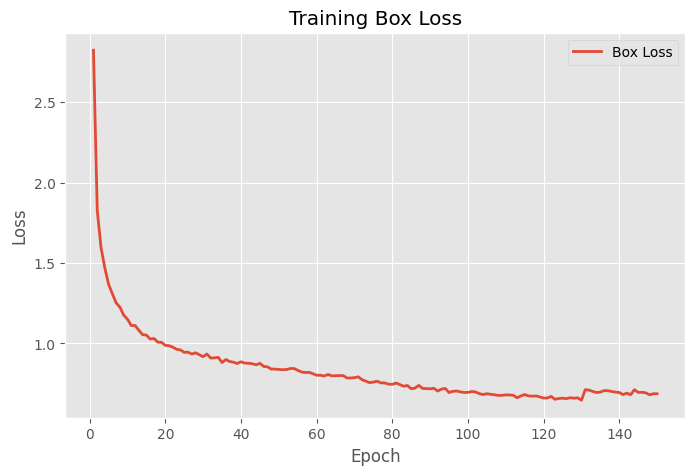

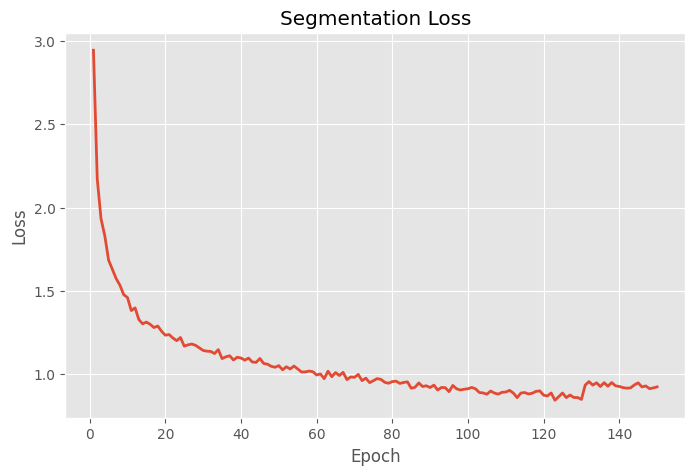

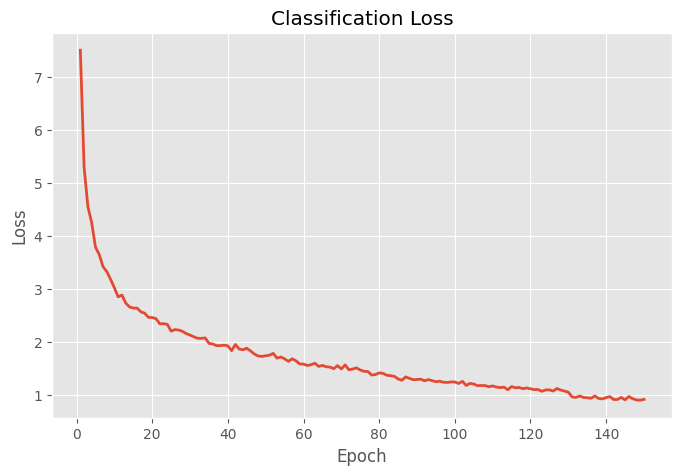

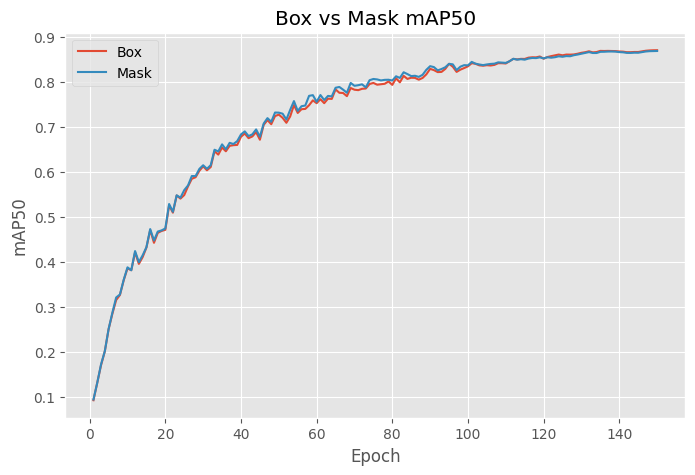

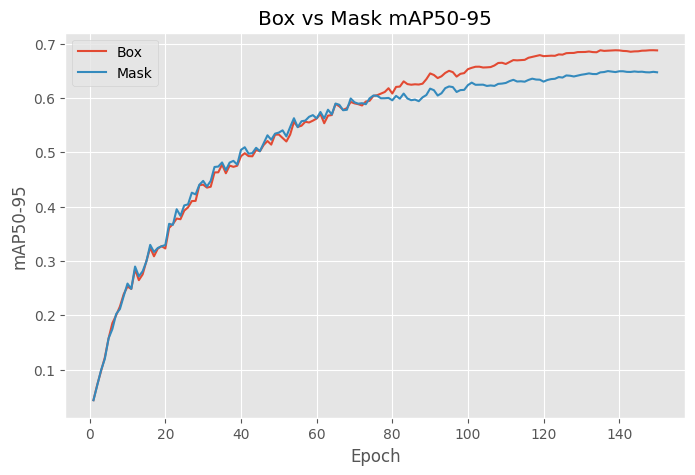

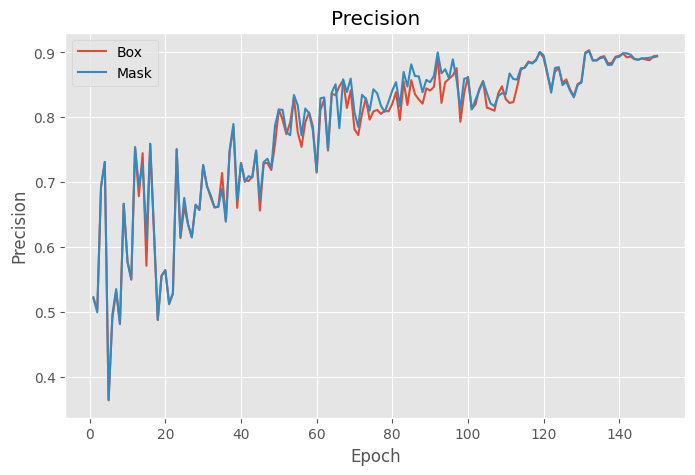

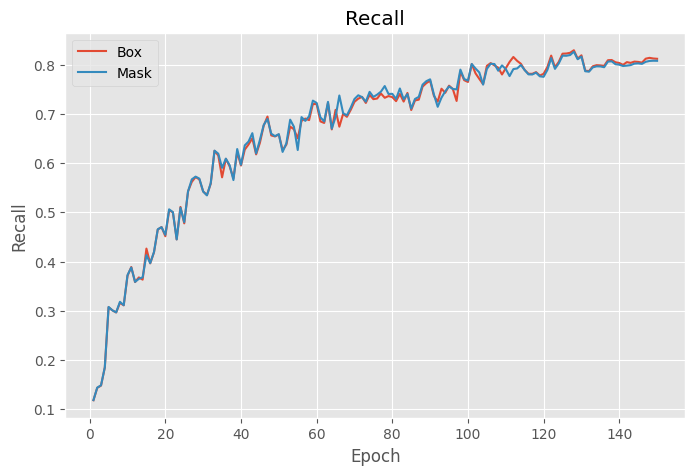

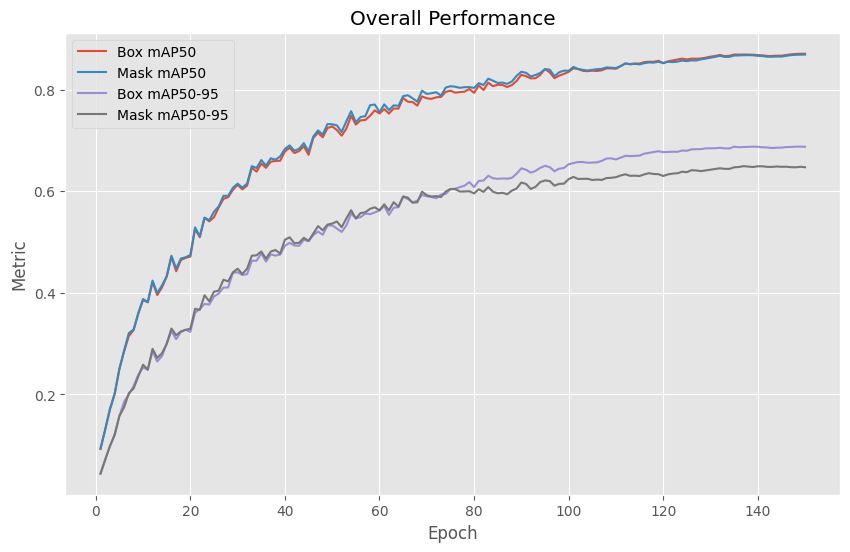

In [24]:
# ============================================
# YOLO11 Training Visualization for Research
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------
# Path to results.csv
# Change if your experiment folder is different
# --------------------------------------------

results_path = Path("//kaggle/working/runs/YOLO11s_CBAM_seg/results.csv")

df = pd.read_csv(results_path)

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Epoch axis
epochs = df["epoch"]

plt.style.use("ggplot")

# ============================================
# 1. Box Loss
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["train/box_loss"], label="Box Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Box Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 2. Segmentation Loss
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["train/seg_loss"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Segmentation Loss")
plt.grid(True)
plt.show()

# ============================================
# 3. Classification Loss
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["train/cls_loss"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss")
plt.grid(True)
plt.show()

# ============================================
# 4. mAP50
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["metrics/mAP50(B)"], label="Box")
plt.plot(epochs, df["metrics/mAP50(M)"], label="Mask")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("Box vs Mask mAP50")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 5. mAP50-95
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["metrics/mAP50-95(B)"], label="Box")
plt.plot(epochs, df["metrics/mAP50-95(M)"], label="Mask")
plt.xlabel("Epoch")
plt.ylabel("mAP50-95")
plt.title("Box vs Mask mAP50-95")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 6. Precision
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["metrics/precision(B)"], label="Box")
plt.plot(epochs, df["metrics/precision(M)"], label="Mask")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 7. Recall
# ============================================

plt.figure(figsize=(8,5))
plt.plot(epochs, df["metrics/recall(B)"], label="Box")
plt.plot(epochs, df["metrics/recall(M)"], label="Mask")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 8. Combined Performance
# ============================================

plt.figure(figsize=(10,6))

plt.plot(epochs, df["metrics/mAP50(B)"], label="Box mAP50")
plt.plot(epochs, df["metrics/mAP50(M)"], label="Mask mAP50")
plt.plot(epochs, df["metrics/mAP50-95(B)"], label="Box mAP50-95")
plt.plot(epochs, df["metrics/mAP50-95(M)"], label="Mask mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Overall Performance")
plt.legend()
plt.grid(True)

plt.show()